# RF Model

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, r2_score
from sklearn.tree import plot_tree

## Data Stuff

In [52]:
#BRING IN THE MOTHER
mother_file = pd.read_csv("data/mother2.csv")
mother_file

# removing a ton of columns that are not helpful
mother_file = mother_file.drop(columns=[col for col in mother_file.columns if 'waste_value_tonnes' in col])
mother_file = mother_file.drop(columns=[col for col in mother_file.columns if 'capacity_value' in col])
mother_file = mother_file.drop(columns=[col for col in mother_file.columns if 'waste_total_material' in col])
mother_file = mother_file.drop(columns=[col for col in mother_file.columns if 'reserves_grade' in col])
mother_file = mother_file.drop(columns=[col for col in mother_file.columns if 'reserves_mineral_value' in col])
mother_file = mother_file.drop(columns=[col for col in mother_file.columns if 'reserves_commodity_value' in col])
mother_file = mother_file.drop(columns=[col for col in mother_file.columns if 'commodities_grade' in col])
mother_file

,facility_id,facility_name,facility_type,primary_commodity,commodities_products,facility_equipment,country,LOM_in_Buckets,still_operating,material,commodity_y,commodities_id_minerals,price_usd_tonne,commodity,id_y,waste_type,2000_clean_coal_value_tonnes,2001_clean_coal_value_tonnes,2002_clean_coal_value_tonnes,2003_clean_coal_value_tonnes,2004_clean_coal_value_tonnes,2005_clean_coal_value_tonnes,2006_clean_coal_value_tonnes,2007_clean_coal_value_tonnes,2008_clean_coal_value_tonnes,2009_clean_coal_value_tonnes,2010_clean_coal_value_tonnes,2011_clean_coal_value_tonnes,2012_clean_coal_value_tonnes,2013_clean_coal_value_tonnes,2014_clean_coal_value_tonnes,2015_clean_coal_value_tonnes,2016_clean_coal_value_tonnes,2017_clean_coal_value_tonnes,2018_clean_coal_value_tonnes,2019_clean_coal_value_tonnes,2020_clean_coal_value_tonnes,2000_coal_mined_value_tonnes,2001_coal_mined_value_tonnes,2002_coal_mined_value_tonnes,...,2002_minerals_ore_mined_value_tonnes,2003_minerals_ore_mined_value_tonnes,2004_minerals_ore_mined_value_tonnes,2005_minerals_ore_mined_value_tonnes,2006_minerals_ore_mined_value_tonnes,2007_minerals_ore_mined_value_tonnes,2008_minerals_ore_mined_value_tonnes,2009_minerals_ore_mined_value_tonnes,2010_minerals_ore_mined_value_tonnes,2011_minerals_ore_mined_value_tonnes,2012_minerals_ore_mined_value_tonnes,2013_minerals_ore_mined_value_tonnes,2014_minerals_ore_mined_value_tonnes,2015_minerals_ore_mined_value_tonnes,2016_minerals_ore_mined_value_tonnes,2017_minerals_ore_mined_value_tonnes,2018_minerals_ore_mined_value_tonnes,2019_minerals_ore_mined_value_tonnes,2020_minerals_ore_mined_value_tonnes,2000_minerals_ore_processed_value_tonnes,2001_minerals_ore_processed_value_tonnes,2002_minerals_ore_processed_value_tonnes,2003_minerals_ore_processed_value_tonnes,2004_minerals_ore_processed_value_tonnes,2005_minerals_ore_processed_value_tonnes,2006_minerals_ore_processed_value_tonnes,2007_minerals_ore_processed_value_tonnes,2008_minerals_ore_processed_value_tonnes,2009_minerals_ore_processed_value_tonnes,2010_minerals_ore_processed_value_tonnes,2011_minerals_ore_processed_value_tonnes,2012_minerals_ore_processed_value_tonnes,2013_minerals_ore_processed_value_tonnes,2014_minerals_ore_processed_value_tonnes,2015_minerals_ore_processed_value_tonnes,2016_minerals_ore_processed_value_tonnes,2017_minerals_ore_processed_value_tonnes,2018_minerals_ore_processed_value_tonnes,2019_minerals_ore_processed_value_tonnes,2020_minerals_ore_processed_value_tonnes
0,COM00003.00,Absaloka,Mine,Coal,Sub-bituminous coal,NaN,United States of America,47.0,1.0,F.sbc,NaN,NaN,43.21,NaN,6.0,NaN,NaN,5356109.0,4681152.0,5457715.0,5885914.0,5863234.0,6149002.0,6667920.0,5797915.0,5315285.0,4958755.0,5023166.0,2483914.0,3755808.0,5998406.0,5336150.0,3751272.0,3235075.0,NaN,NaN,NaN,NaN,5356109.0,4681152.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,COM00008.00,Aguablanca,Mine,Nickel,"Nickel, Copper, Cobalt, Gold, PGM",Underground,Spain,11.0,0.0,O.bulk,NaN,76.0,16811.81,Me.Cu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,997224.0,1550437.0,1707330.0,1794089.0,1441903.0,1349336.0,24289.0,755000.0,1785000.0,1755000.0,616000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,997224.0,1486800.0,1668959.0,1825212.0,1912675.0,1435177.0,0.0,577000.0,1606000.0,1660000.0,1292000.0,NaN,NaN,NaN,NaN,NaN
2,COM00009.00,Ahafo,Mine,Gold,Gold,"Open pit, Underground",Ghana,15.0,1.0,O.Au,NaN,NaN,672.01,Me.Au,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,8094946.0,11101406.0,10416470.0,11122272.0,14181350.0,12576514.0,16135459.0,11909722.0,6546355.0,5836925.0,6631632.0,7319290.0,7764725.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7339248.0,7495286.0,7561512.0,7595078.0,7814621.0,7605965.0,7774704.0,7004491.0,6637075.0,7269394.0

In [53]:
# Split on facility_id
facilities = mother_file["facility_id"].unique()
train_facilities, test_facilities = train_test_split(facilities, test_size=0.2, random_state=42)

train_df = mother_file[mother_file["facility_id"].isin(train_facilities)]
test_df  = mother_file[mother_file["facility_id"].isin(test_facilities)]

print(f"Train rows : {len(train_df)} ({len(train_facilities)} facilities)")
print(f"Test rows  : {len(test_df)} ({len(test_facilities)} facilities)")

# Extract target variable
y_train = train_df["LOM_in_Buckets"]
y_test  = test_df["LOM_in_Buckets"]

# Drop unwanted columns (found after other data processing steps)to create feature matrices
drop_cols = ["id", "id_x", "id_y", "commodity_y", "comment",
             "facility_name", "facility_type", "reserves_commodity_value_tonnes", "LOM_in_Buckets"]
X_train = train_df.drop(columns=drop_cols, errors="ignore").select_dtypes(include="number")
X_test  = test_df.drop(columns=drop_cols, errors="ignore").select_dtypes(include="number")

#we had a problem with infinite values accidentally :( 
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

# Drop rows where target variable doesn't exist
mask_train = y_train.notna()
mask_test  = y_test.notna()
X_train, y_train = X_train[mask_train], y_train[mask_train]
X_test,  y_test  = X_test[mask_test],  y_test[mask_test]

# Fill NaNs in features with training median
X_train = X_train.fillna(X_train.median())
X_test  = X_test.fillna(X_train.median())

print(f"\nFeatures used : {list(X_train.columns)}")
print(f"Train samples : {len(X_train)}")
print(f"Test samples  : {len(X_test)}")

Train rows : 321 (321 facilities)
Test rows  : 81 (81 facilities)

Features used : ['still_operating', 'commodities_id_minerals', 'price_usd_tonne', '2000_clean_coal_value_tonnes', '2001_clean_coal_value_tonnes', '2002_clean_coal_value_tonnes', '2003_clean_coal_value_tonnes', '2004_clean_coal_value_tonnes', '2005_clean_coal_value_tonnes', '2006_clean_coal_value_tonnes', '2007_clean_coal_value_tonnes', '2008_clean_coal_value_tonnes', '2009_clean_coal_value_tonnes', '2010_clean_coal_value_tonnes', '2011_clean_coal_value_tonnes', '2012_clean_coal_value_tonnes', '2013_clean_coal_value_tonnes', '2014_clean_coal_value_tonnes', '2015_clean_coal_value_tonnes', '2016_clean_coal_value_tonnes', '2017_clean_coal_value_tonnes', '2018_clean_coal_value_tonnes', '2019_clean_coal_value_tonnes', '2020_clean_coal_value_tonnes', '2000_coal_mined_value_tonnes', '2001_coal_mined_value_tonnes', '2002_coal_mined_value_tonnes', '2003_coal_mined_value_tonnes', '2004_coal_mined_value_tonnes', '2005_coal_mined_va

In [54]:
# we're having some trouble with X, let's see what it is -- as it turns out, some values were infinite
print(X_train)
pd.DataFrame(X_train).to_csv('data/X_train_check.csv', index=False)

     still_operating  ...  2020_minerals_ore_processed_value_tonnes
1                0.0  ...                                 1973000.0
2                1.0  ...                                 1973000.0
4                1.0  ...                                 1973000.0
6                0.0  ...                                 1973000.0
7                1.0  ...                                 1973000.0
..               ...  ...                                       ...
392              1.0  ...                                 1973000.0
394              1.0  ...                                 1973000.0
395              1.0  ...                                 1973000.0
399              1.0  ...                                 1973000.0
401              1.0  ...                                 1973000.0

[321 rows x 174 columns]


## Model Stuff

In [ ]:
model = RandomForestRegressor()
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)
# print(y_pred_train)
# print(y_pred_test)

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print(f"R^2  — Train: {r2_train:.4f} | Test: {r2_test:.4f}")


R²  — Train: 0.8423 | Test: 0.0059


In [ ]:
# # adapted from Pset 1 Q3 and Pset 3 Q3
param_grid = {
    'max_depth': (1, 3, 5, 10),
    'min_samples_leaf': (1, 5, 20)
    # 'criterion': (“squared_error”, “absolute_error”, “friedman_mse”, “poisson”)
}

tree = RandomForestRegressor()
grid_tree = GridSearchCV(estimator=tree,
                         param_grid=param_grid,
                         scoring='r2',
                         cv=5)

grid_tree.fit(X_train,y_train)
grid_model = grid_tree.best_estimator_

y_pred_train_grid = grid_model.predict(X_train)
y_pred_test_grid = grid_model.predict(X_test)

# accuracy_train_grid = accuracy_score(y_train, y_pred_train_grid)
# accuracy_test_grid = accuracy_score(y_test, y_pred_test_grid)

print("best accuracy", grid_tree.best_score_)
print("best params", grid_tree.best_params_)

# print(f'Train Accuracy = {accuracy_train_grid}')
# print(f'Test Accuracy = {accuracy_test_grid}')

r2_train_grid = r2_score(y_train, y_pred_train_grid)
r2_test_grid = r2_score(y_test, y_pred_test_grid)

print(f"R^2  — Train: {r2_train_grid:.4f} | Test: {r2_test_grid:.4f}")


best accuracy 0.14235753693787004
best params {'max_depth': 5, 'min_samples_leaf': 20}
R²  — Train: 0.1962 | Test: 0.0151


## Plotting Stuff

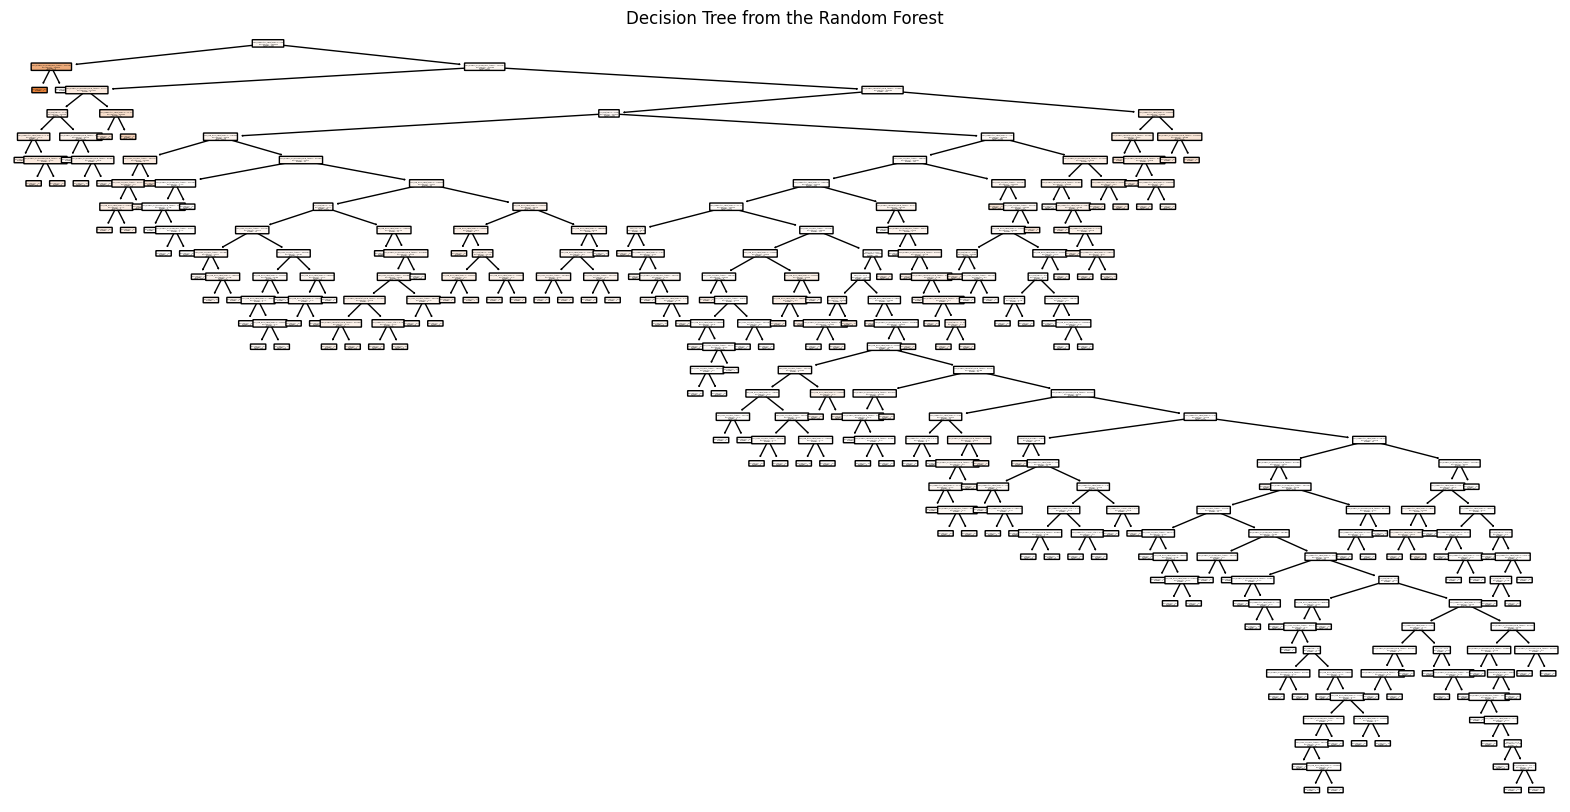

In [57]:
tree = model.estimators_[0]

plt.figure(figsize=(20,10)) 
plot_tree(tree,
          filled=True,              
          feature_names=X_train.columns.tolist(),
          rounded=True)             # make things pretty
plt.title("Decision Tree from the Random Forest")
plt.show()

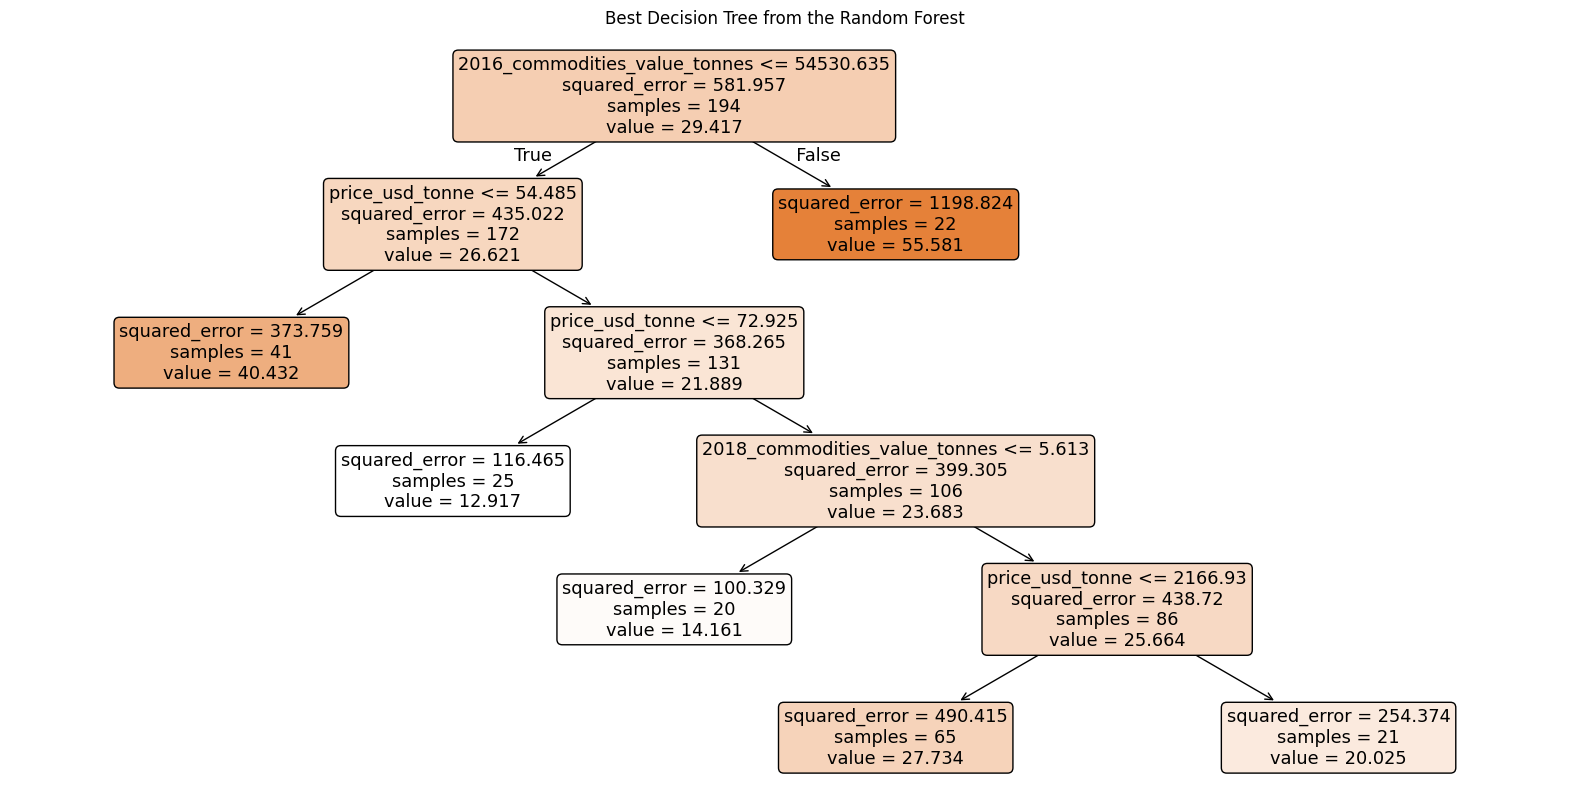

In [58]:
grid_tree = grid_model.estimators_[0]

plt.figure(figsize=(20,10)) 
plot_tree(grid_tree,
          filled=True,              
          feature_names=X_train.columns.tolist(),
          rounded=True)             
plt.title("Best Decision Tree from the Random Forest")
plt.show()